In [35]:
import pandas as pd

df = pd.read_csv("degismeyen.csv")

print("Toplam örnek sayısı:", len(df))

print("Benzersiz kişi sayısı:", df['name'].nunique())

print("\nKişi başına kayıt sayıları:")
print(df['name'].value_counts())


Toplam örnek sayısı: 195
Benzersiz kişi sayısı: 195

Kişi başına kayıt sayıları:
name
phon_R01_S01_1    1
phon_R01_S01_2    1
phon_R01_S01_3    1
phon_R01_S01_4    1
phon_R01_S01_5    1
                 ..
phon_R01_S50_2    1
phon_R01_S50_3    1
phon_R01_S50_4    1
phon_R01_S50_5    1
phon_R01_S50_6    1
Name: count, Length: 195, dtype: int64


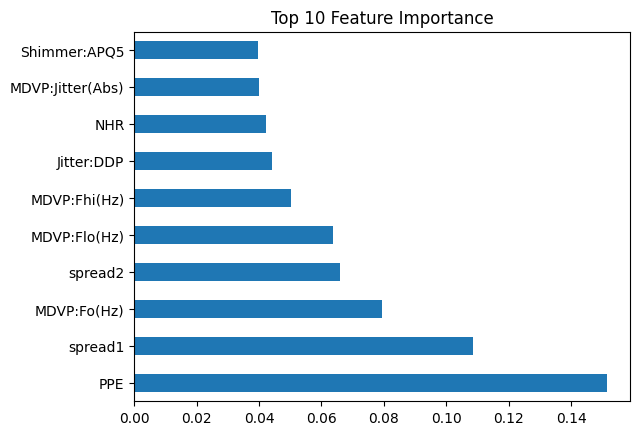

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("degismeyen.csv")

X = df.drop(columns=["name","status"])
y = df["status"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

top10.plot(kind="barh")
plt.title("Top 10 Feature Importance")
plt.show()


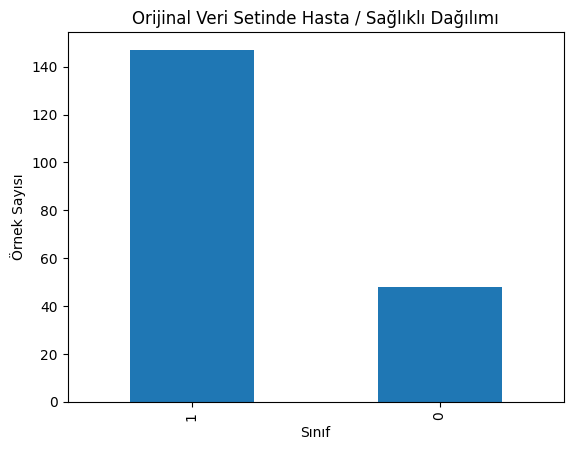

In [37]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Orijinal Veri Setinde Hasta / Sağlıklı Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")
plt.show()


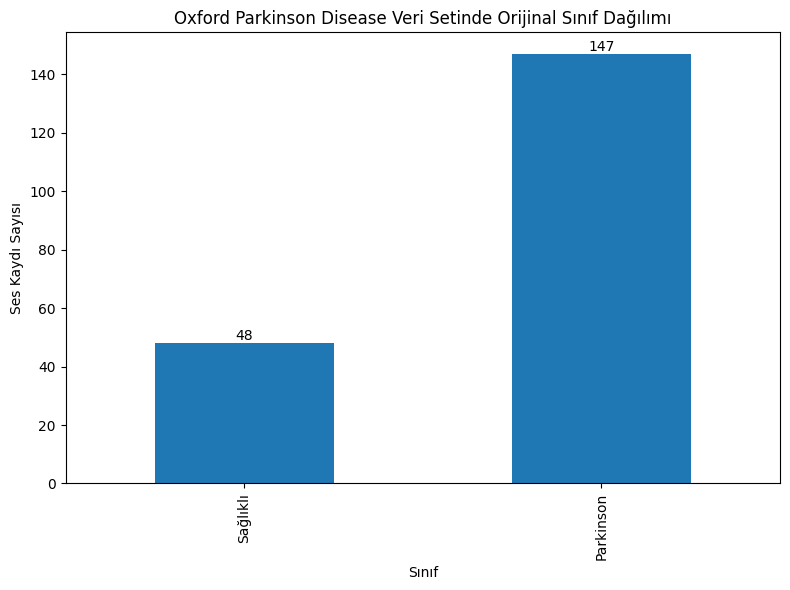

In [50]:
import matplotlib.pyplot as plt

# 0/1 etiketlerini anlamlı isimlere çevir
label_map = {0: "Sağlıklı", 1: "Parkinson"}

counts = y.value_counts().sort_index()
counts.index = counts.index.map(label_map)
plt.figure(figsize=(8,6))
# Bar plot
counts.plot(kind="bar")

plt.title("Oxford Parkinson Disease Veri Setinde Orijinal Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Ses Kaydı Sayısı")
plt.bar_label(plt.gca().containers[0])

plt.tight_layout()

plt.savefig("degismeyen.pdf")

plt.show()


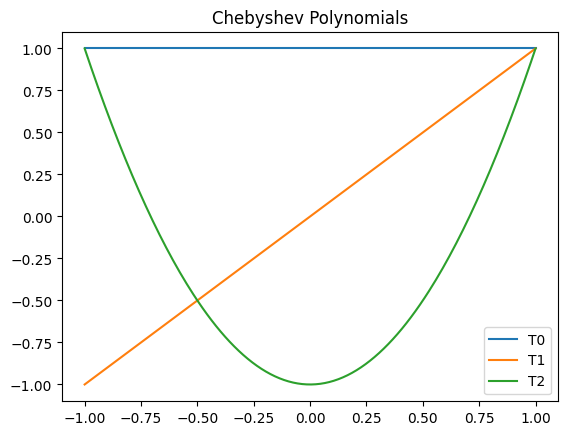

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebval

x = np.linspace(-1, 1, 200)

T0 = chebval(x, [1])
T1 = chebval(x, [0,1])
T2 = chebval(x, [0,0,1])

plt.plot(x, T0, label="T0")
plt.plot(x, T1, label="T1")
plt.plot(x, T2, label="T2")
plt.legend()
plt.title("Chebyshev Polynomials")
plt.show()


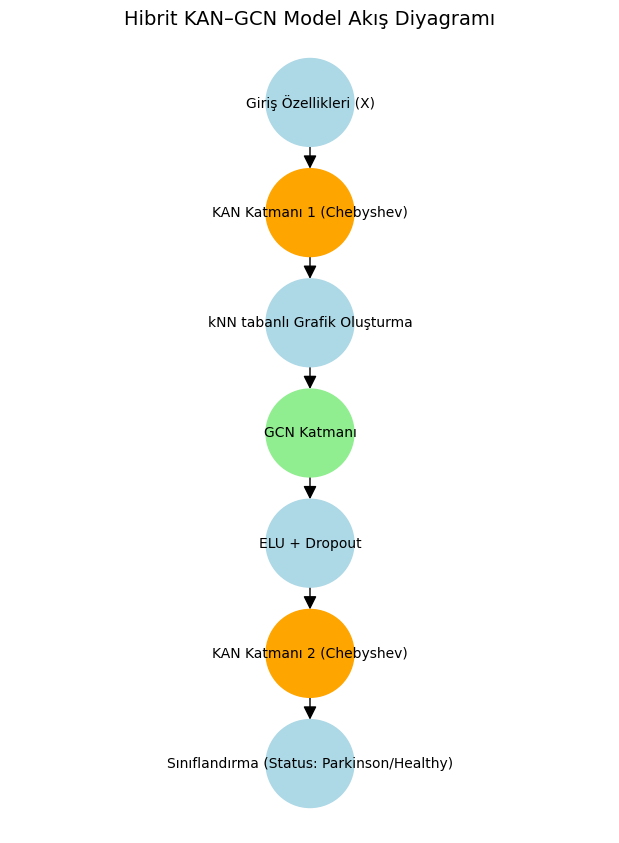

In [52]:
import matplotlib.pyplot as plt
import networkx as nx

# Blokları ve akışlarını tanımla
edges = [
    ("Giriş Özellikleri (X)", "KAN Katmanı 1 (Chebyshev)"),
    ("KAN Katmanı 1 (Chebyshev)", "kNN tabanlı Grafik Oluşturma"),
    ("kNN tabanlı Grafik Oluşturma", "GCN Katmanı"),
    ("GCN Katmanı", "ELU + Dropout"),
    ("ELU + Dropout", "KAN Katmanı 2 (Chebyshev)"),
    ("KAN Katmanı 2 (Chebyshev)", "Sınıflandırma (Status: Parkinson/Healthy)")
]

# Node renklerini belirle
color_map = {
    "Giriş Özellikleri (X)": "lightblue",
    "KAN Katmanı 1 (Chebyshev)": "orange",
    "kNN tabanlı Grafik Oluşturma": "lightblue",
    "GCN Katmanı": "lightgreen",
    "ELU + Dropout": "lightblue",
    "KAN Katmanı 2 (Chebyshev)": "orange",
    "Sınıflandırma (Status: Parkinson/Healthy)": "lightblue"
}

# NetworkX grafiği oluştur
G = nx.DiGraph()
G.add_edges_from(edges)

# Pozisyonları dikey akış için manuel ayarla
pos = {node: (0, i) for i, node in enumerate(range(len(edges), 0, -1))}
# Node isimlerini doğru konumlandırmak için
pos = {
    "Giriş Özellikleri (X)": (0, 6),
    "KAN Katmanı 1 (Chebyshev)": (0, 5),
    "kNN tabanlı Grafik Oluşturma": (0, 4),
    "GCN Katmanı": (0, 3),
    "ELU + Dropout": (0, 2),
    "KAN Katmanı 2 (Chebyshev)": (0, 1),
    "Sınıflandırma (Status: Parkinson/Healthy)": (0, 0)
}

# Renk listesi oluştur
node_colors = [color_map[node] for node in G.nodes()]

# Grafiği çiz
plt.figure(figsize=(6, 8))
nx.draw(G, pos, with_labels=True, node_size=4000, node_color=node_colors,
        arrowsize=20, arrowstyle='-|>', font_size=10)
plt.title("Hibrit KAN–GCN Model Akış Diyagramı", fontsize=14)
plt.axis('off')
plt.show()


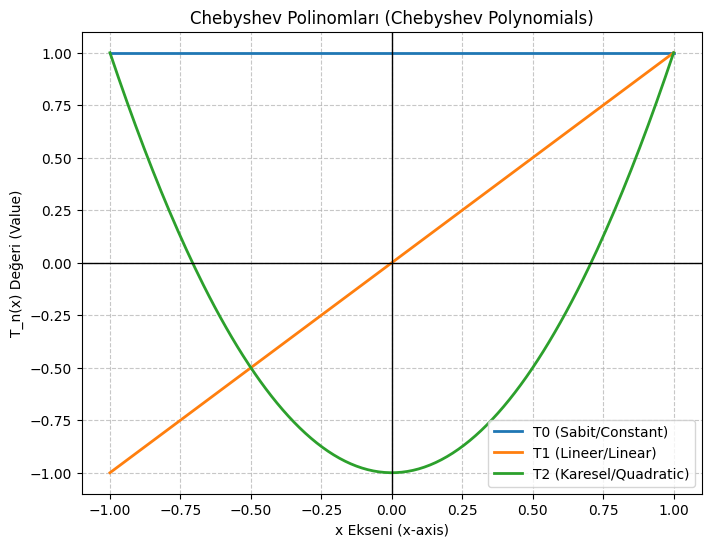

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebval

x = np.linspace(-1, 1, 200)

# Katsayı dizileri: [T0, T1, T2] sırasıyla dereceleri temsil eder
T0 = chebval(x, [1])          # T0(x) = 1
T1 = chebval(x, [0, 1])       # T1(x) = x
T2 = chebval(x, [0, 0, 1])    # T2(x) = 2x^2 - 1

plt.figure(figsize=(8, 6))

plt.plot(x, T0, label="T0 (Sabit/Constant)", linewidth=2)
plt.plot(x, T1, label="T1 (Lineer/Linear)", linewidth=2)
plt.plot(x, T2, label="T2 (Karesel/Quadratic)", linewidth=2)

# ---- HOCANIN İSTEDİĞİ EKLEMELER ----

# 1. Eksen Etiketleri (Türkçe ve İngilizce)
plt.xlabel("x Ekseni (x-axis)")
plt.ylabel("T_n(x) Değeri (Value)")

# 2. Izgara (Grid) Ekleme
plt.grid(True, linestyle='--', alpha=0.7)

# 3. X ve Y Eksenlerini Belirginleştirme (Sıfır çizgileri)
plt.axhline(0, color='black', linewidth=1) # Yatay eksen çizgisi
plt.axvline(0, color='black', linewidth=1) # Dikey eksen çizgisi

# ----------------------------------

plt.legend()
plt.title("Chebyshev Polinomları (Chebyshev Polynomials)")

# PDF olarak kaydetmek istersen:
plt.savefig("Chebyshev_Grafigi.pdf", bbox_inches='tight')

plt.show()

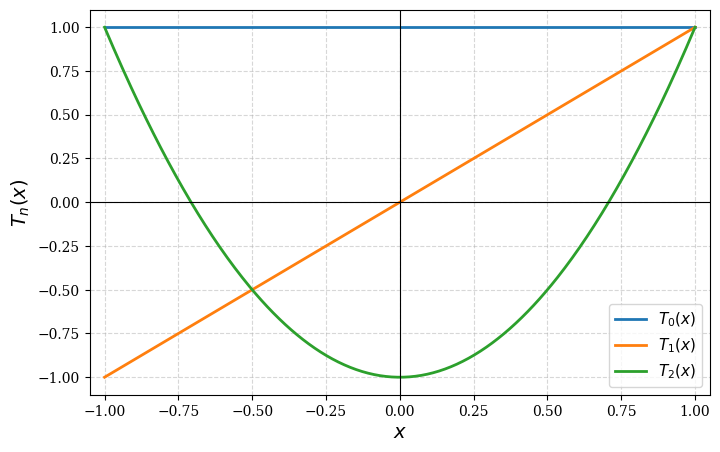

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebval

# Akademik görünüm için font ayarları
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], # LaTeX fontlarına benzer bir görünüm sağlar
})

x = np.linspace(-1, 1, 400)

# Katsayı dizileri: T0, T1, T2 sırasıyla dereceleri temsil eder
T0 = chebval(x, [1])       # T0(x) = 1
T1 = chebval(x, [0, 1])    # T1(x) = x
T2 = chebval(x, [0, 0, 1]) # T2(x) = 2x^2 - 1

plt.figure(figsize=(8, 5))

# Çizimler - Matematiksel formatta etiketler ($ sembolleri arası LaTeX formatıdır)
plt.plot(x, T0, label=r"$T_0(x)$", linewidth=2)
plt.plot(x, T1, label=r"$T_1(x)$", linewidth=2)
plt.plot(x, T2, label=r"$T_2(x)$", linewidth=2)

# ---- AKADEMİK DÜZENLEMELER ----

# 1. Eksen Etiketleri (Sadece semboller kullanılır)
plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$T_n(x)$", fontsize=14)

# 2. Hafif Izgara (Grid)
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Sıfır Çizgilerini Belirginleştirme
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# 4. Lejant (Kutu çerçevesini koruyarak sağ alta yerleştiriyoruz)
plt.legend(loc='lower right', fontsize=11, frameon=True)

# Eksen sınırlarını netleştirme (Görüntünün kenarlara çok yapışmaması için)
plt.xlim([-1.05, 1.05])
plt.ylim([-1.1, 1.1])

# ----------------------------------

# Hem PNG (görsel için) hem PDF (en yüksek kalite için) olarak kaydetme
plt.savefig("Chebyshev_Akademik.png", dpi=300, bbox_inches='tight')
plt.savefig("Chebyshev_Akademik.pdf", bbox_inches='tight')

plt.show()